# Data Cleaning

In [1]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
atm = pd.read_csv(r'Dataset/ATM_Maintenance.csv')
atm

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H
0,2025-01-01,ATM058,Idukki,Hospital,NCR,1.2,429,15,69.0,0,...,52,46,0,78,2,29,4,1,5,1
1,2025-01-02,ATM173,Kozhikode,Railway,Diebold,1.9,343,6,43.0,0,...,45,10,0,92,3,58,1,0,2,1
2,2025-01-03,ATM187,Malappuram,Airport,Diebold,2.5,285,10,78.0,0,...,53,66,2,88,0,63,0,0,0,0
3,2025-01-04,ATM256,Alappuzha,Rural,Diebold,4.6,488,22,39.0,0,...,67,95,1,68,1,54,0,0,5,1
4,2025-01-05,ATM284,Thrissur,Hospital,NCR,8.7,736,25,57.0,0,...,54,56,3,97,4,57,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-12-22,ATM153,Kottayam,Airport,Diebold,8.1,595,29,69.0,0,...,58,177,0,79,3,5,0,0,1,1
49996,2025-12-23,ATM229,Kollam,Airport,Hitachi,7.3,578,11,85.0,1,...,67,41,3,77,3,70,6,1,0,0
49997,2025-12-24,ATM247,Thrissur,Hospital,Diebold,6.2,656,1,35.0,0,...,65,64,0,89,0,43,4,2,0,0
49998,2025-12-25,ATM184,Kottayam,Railway,NCR,1.9,471,19,62.0,0,...,71,114,0,100,1,0,2,3,1,1


In [3]:
atm.head()

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H
0,2025-01-01,ATM058,Idukki,Hospital,NCR,1.2,429,15,69.0,0,...,52,46,0,78,2,29,4,1,5,1
1,2025-01-02,ATM173,Kozhikode,Railway,Diebold,1.9,343,6,43.0,0,...,45,10,0,92,3,58,1,0,2,1
2,2025-01-03,ATM187,Malappuram,Airport,Diebold,2.5,285,10,78.0,0,...,53,66,2,88,0,63,0,0,0,0
3,2025-01-04,ATM256,Alappuzha,Rural,Diebold,4.6,488,22,39.0,0,...,67,95,1,68,1,54,0,0,5,1
4,2025-01-05,ATM284,Thrissur,Hospital,NCR,8.7,736,25,57.0,0,...,54,56,3,97,4,57,0,0,0,0


In [4]:
atm.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    50000 non-null  str    
 1   ATM_ID                  50000 non-null  str    
 2   District                50000 non-null  str    
 3   Location_Type           50000 non-null  str    
 4   Manufacturer            50000 non-null  str    
 5   ATM_Age_Yrs             49480 non-null  float64
 6   Daily_Transactions      50000 non-null  int64  
 7   Failed_Transactions     50000 non-null  int64  
 8   Cash_Remaining_Pct      49533 non-null  float64
 9   Cash_Loaded_Today       50000 non-null  int64  
 10  CardReader_Errors       50000 non-null  int64  
 11  CashDispenser_Errors    50000 non-null  int64  
 12  Cash_Jams               50000 non-null  int64  
 13  Printer_Errors          50000 non-null  int64  
 14  Paper_Remaining_Pct     50000 non-null  int64  
 

In [5]:
atm.duplicated().sum()

np.int64(0)

In [6]:
atm.isna().sum()

Date                        0
ATM_ID                      0
District                    0
Location_Type               0
Manufacturer                0
ATM_Age_Yrs               520
Daily_Transactions          0
Failed_Transactions         0
Cash_Remaining_Pct        467
Cash_Loaded_Today           0
CardReader_Errors           0
CashDispenser_Errors        0
Cash_Jams                   0
Printer_Errors              0
Paper_Remaining_Pct         0
CPU_Temp_C                  0
CPU_Usage_Pct               0
Memory_Usage_Pct            0
Network_Latency_ms          0
Network_Drops               0
UPS_Battery_Pct             0
Power_Outages_7D            0
Days_Since_Maintenance      0
Previous_Failures_90D       0
Customer_Complaints_7D      0
Failure_Code                0
Failure_Next_48H            0
dtype: int64

In [7]:
atm['ATM_Age_Yrs'].unique()

array([ 1.2,  1.9,  2.5,  4.6,  8.7,  9.3,  9.4,  7.5,  2.3,  7. ,  6.6,
        4.9,  1.4,  4.2,  4.1,  3.9,  1.8,  5.2,  1.7,  5.8,  6.1,  5. ,
        3.3,  4.8,  8.3,  7.4,  3.4,  5.5,  8.9,  2. ,  6.7,  9.7,  6.8,
        9.5,  9.9,  1.5,  5.4,  4.4,  3.2,  2.6,  6.5,  4.7,  6. ,  6.4,
        7.9,  5.9,  5.7,  8.5,  7.2,  7.1,  2.8,  3.8,  6.3, 10. ,  8.1,
        1.6,  2.2,  3.5,  3.7,  2.7,  8.4,  4.5,  3.6,  9. ,  7.7,  3. ,
        2.4,  1.3,  5.3,  4. ,  2.9,  6.9,  5.6,  8. ,  1. ,  nan,  9.2,
        7.8,  4.3,  7.3,  8.6,  9.1,  7.6,  6.2,  8.2,  9.8,  5.1,  3.1,
        8.8,  1.1,  2.1,  9.6])

In [8]:
atm['Cash_Remaining_Pct'].unique()

array([ 69.,  43.,  78.,  39.,  57.,  45.,  24.,  41.,  75.,  60.,  67.,
        36.,  64.,  93.,  18.,  87.,  30.,  56.,  46.,  19.,  33.,  85.,
        81.,  47.,  49.,  51.,  73.,  28.,  84.,  38.,  58.,  80.,  74.,
        44.,  nan,  22.,  68.,  48.,  17.,  42.,  21.,  54.,  26.,  31.,
        79.,   3.,   8.,  59.,  83.,  53.,  23.,  70.,  82.,  55.,  66.,
        77., 100.,  27.,  35.,  65.,  63.,  32.,  91.,  29.,  76.,  62.,
        34.,  89.,  99.,  72.,  40.,  11.,  92.,  20.,  52.,  96.,  50.,
         0.,   2.,  88.,  90.,  14.,   7.,  61.,  71.,  37.,  95.,   5.,
        86.,  98.,   9.,  97.,  25.,  16.,  12.,  15.,   6.,  13.,  94.,
         1.,  10.,   4.])

In [9]:
atm['ATM_Age_Yrs'].mode()

0    9.4
Name: ATM_Age_Yrs, dtype: float64

In [10]:
atm['Cash_Remaining_Pct'].mode()

0    54.0
Name: Cash_Remaining_Pct, dtype: float64

In [11]:
numeric_categories = ['ATM_Age_Yrs', 'Cash_Remaining_Pct']
for i in numeric_categories:
    atm[i] = atm[i].fillna(atm[i].mode()[0])

In [12]:
atm.isna().sum()

Date                      0
ATM_ID                    0
District                  0
Location_Type             0
Manufacturer              0
ATM_Age_Yrs               0
Daily_Transactions        0
Failed_Transactions       0
Cash_Remaining_Pct        0
Cash_Loaded_Today         0
CardReader_Errors         0
CashDispenser_Errors      0
Cash_Jams                 0
Printer_Errors            0
Paper_Remaining_Pct       0
CPU_Temp_C                0
CPU_Usage_Pct             0
Memory_Usage_Pct          0
Network_Latency_ms        0
Network_Drops             0
UPS_Battery_Pct           0
Power_Outages_7D          0
Days_Since_Maintenance    0
Previous_Failures_90D     0
Customer_Complaints_7D    0
Failure_Code              0
Failure_Next_48H          0
dtype: int64

In [13]:
atm['Date'] = pd.to_datetime(atm['Date'], format='mixed')

In [14]:
atm.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    50000 non-null  datetime64[us]
 1   ATM_ID                  50000 non-null  str           
 2   District                50000 non-null  str           
 3   Location_Type           50000 non-null  str           
 4   Manufacturer            50000 non-null  str           
 5   ATM_Age_Yrs             50000 non-null  float64       
 6   Daily_Transactions      50000 non-null  int64         
 7   Failed_Transactions     50000 non-null  int64         
 8   Cash_Remaining_Pct      50000 non-null  float64       
 9   Cash_Loaded_Today       50000 non-null  int64         
 10  CardReader_Errors       50000 non-null  int64         
 11  CashDispenser_Errors    50000 non-null  int64         
 12  Cash_Jams               50000 non-null  int64         
 1

In [15]:
atm['Location_Type'].unique()

<StringArray>
['Hospital', 'Railway', 'Airport', 'Rural', 'Mall', 'Branch', 'branch']
Length: 7, dtype: str

In [16]:
atm['Location_Type'] = atm['Location_Type'].replace({"branch": "Branch"})

In [17]:
atm['Manufacturer'].unique()

<StringArray>
['NCR', 'Diebold', 'Hitachi', 'N C R']
Length: 4, dtype: str

In [18]:
atm['Manufacturer'] = atm['Manufacturer'].replace({"N C R": "NCR"})

In [19]:
atm['District'].unique()

<StringArray>
[     'Idukki',   'Kozhikode',  'Malappuram',   'Alappuzha',    'Thrissur',
    'Kottayam',    'Palakkad',   'Ernakulam',   'Thrissur ',      'Kannur',
      'idukki',      'Kollam',   'Kottayam ',   'alappuzha',   'Palakkad ',
      'kollam',     'Idukki ',  'Kozhikode ',  'Alappuzha ',    'thrissur',
    'palakkad',  'malappuram', 'Malappuram ',     'Kollam ',    'kottayam',
   'kozhikode',  'Ernakulam ',   'ernakulam',      'kannur',     'Kannur ']
Length: 30, dtype: str

In [20]:
atm['District'] = atm['District'].replace({'idukki': 'Idukki', 'Idukki ': 'Idukki', 'kottayam': 'Kottayam', 'Kottayam ': 'Kottayam',
                                           'kollam': 'Kollam', 'Kollam ': 'Kollam', 'palakkad': 'Palakkad', 'Palakkad ': 'Palakkad',
                                           'kozhikode': 'Kozhikode', 'Kozhikode ': 'Kozhikode', 'malappuram': 'Malappuram', 'Malappuram ': 'Malappuram',
                                           'ernakulam': 'Ernakulam', 'Ernakulam ': 'Ernakulam', 'kannur': 'Kannur', 'Kannur ': 'Kannur',
                                           'thrissur': 'Thrissur', 'Thrissur ': 'Thrissur', 'alappuzha': 'Alappuzha', 'Alappuzha ': 'Alappuzha'})

In [21]:
atm['District'].unique()

<StringArray>
[    'Idukki',  'Kozhikode', 'Malappuram',  'Alappuzha',   'Thrissur',
   'Kottayam',   'Palakkad',  'Ernakulam',     'Kannur',     'Kollam']
Length: 10, dtype: str

- This particular dataset contains 50000 entries labelled from 0 to 49999.
- It has total 27 columns.
- This data set doesn't have any duplicates but 2 columns contains namely ATM_Age_Yrs and Cash_Remaining_Pct contains some null values.
- Now this data is cleaned and doesn't have any null values.

In [22]:
atm.to_csv(r'Dataset/ATM_Maintenance_Cleaned.csv', index=False)

# Data Visualization (EDA)

In [23]:
atm

,Date,ATM_ID,District,Location_Type,Manufacturer,ATM_Age_Yrs,Daily_Transactions,Failed_Transactions,Cash_Remaining_Pct,Cash_Loaded_Today,...,Memory_Usage_Pct,Network_Latency_ms,Network_Drops,UPS_Battery_Pct,Power_Outages_7D,Days_Since_Maintenance,Previous_Failures_90D,Customer_Complaints_7D,Failure_Code,Failure_Next_48H
0,2025-01-01,ATM058,Idukki,Hospital,NCR,1.2,429,15,69.0,0,...,52,46,0,78,2,29,4,1,5,1
1,2025-01-02,ATM173,Kozhikode,Railway,Diebold,1.9,343,6,43.0,0,...,45,10,0,92,3,58,1,0,2,1
2,2025-01-03,ATM187,Malappuram,Airport,Diebold,2.5,285,10,78.0,0,...,53,66,2,88,0,63,0,0,0,0
3,2025-01-04,ATM256,Alappuzha,Rural,Diebold,4.6,488,22,39.0,0,...,67,95,1,68,1,54,0,0,5,1
4,2025-01-05,ATM284,Thrissur,Hospital,NCR,8.7,736,25,57.0,0,...,54,56,3,97,4,57,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-12-22,ATM153,Kottayam,Airport,Diebold,8.1,595,29,69.0,0,...,58,177,0,79,3,5,0,0,1,1
49996,2025-12-23,ATM229,Kollam,Airport,Hitachi,7.3,578,11,85.0,1,...,67,41,3,77,3,70,6,1,0,0
49997,2025-12-24,ATM247,Thrissur,Hospital,Diebold,6.2,656,1,35.0,0,...,65,64,0,89,0,43,4,2,0,0
49998,2025-12-25,ATM184,Kottayam,Railway,NCR,1.9,471,19,62.0,0,...,71,114,0,100,1,0,2,3,1,1


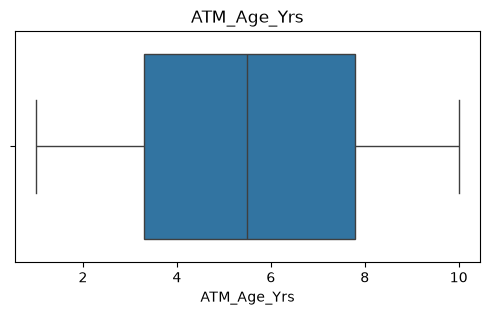

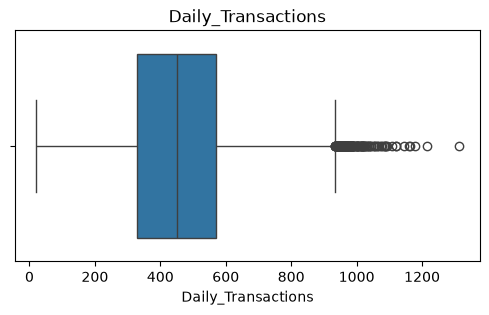

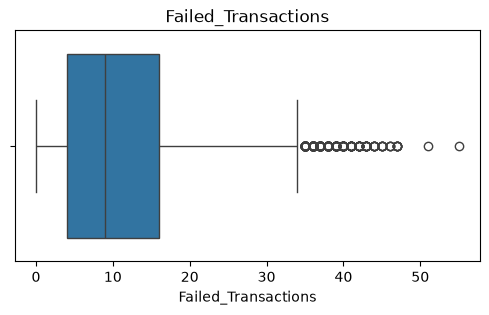

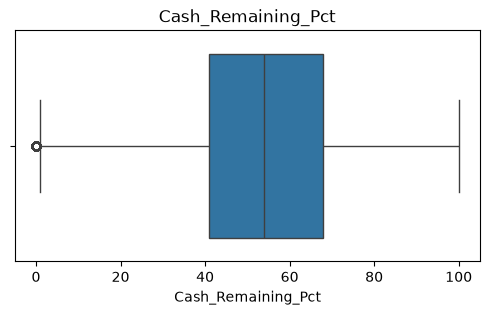

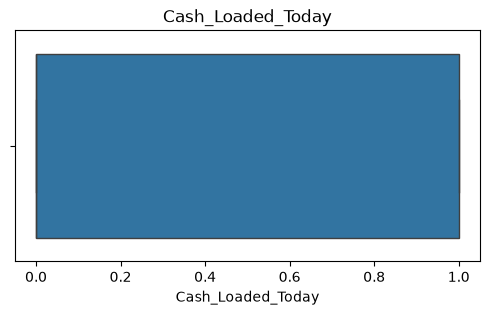

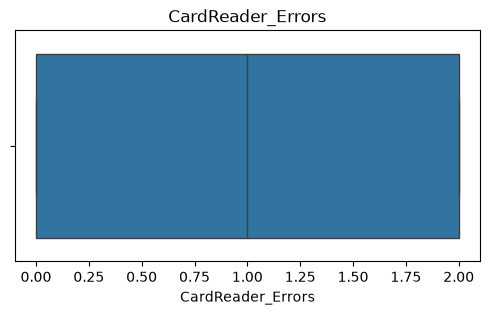

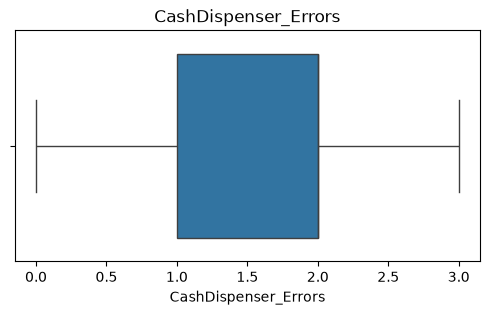

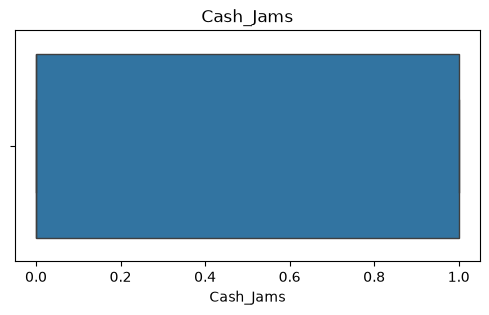

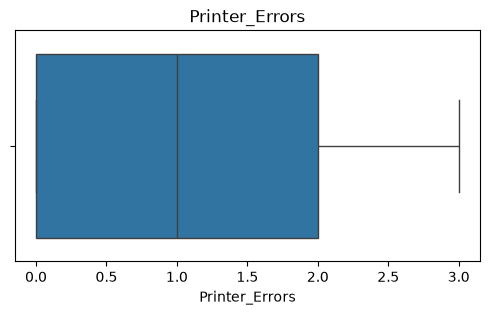

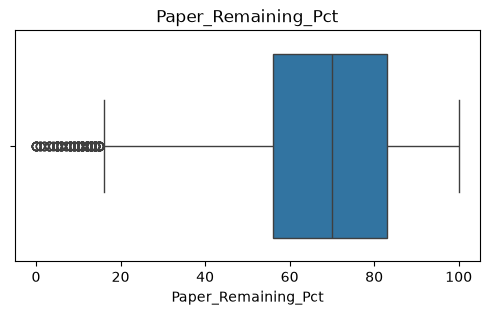

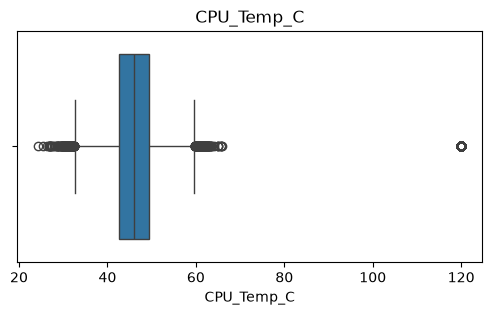

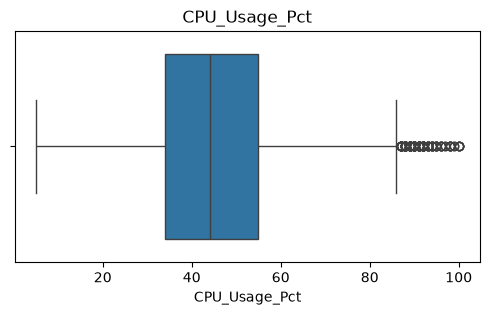

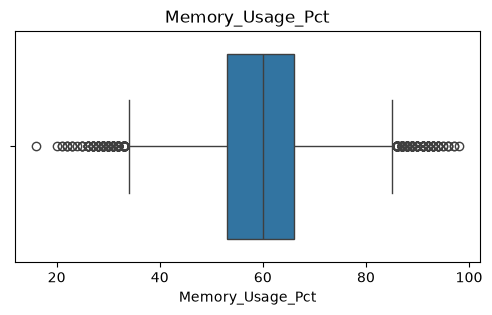

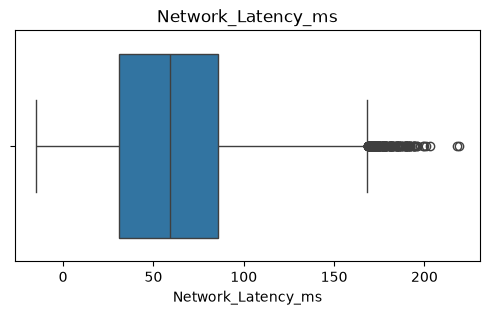

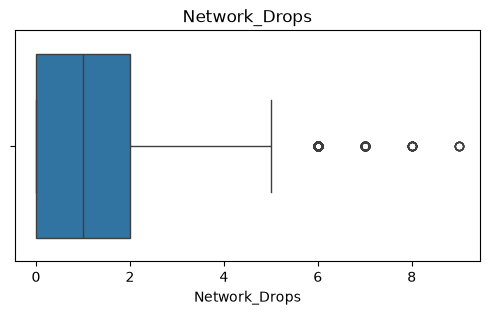

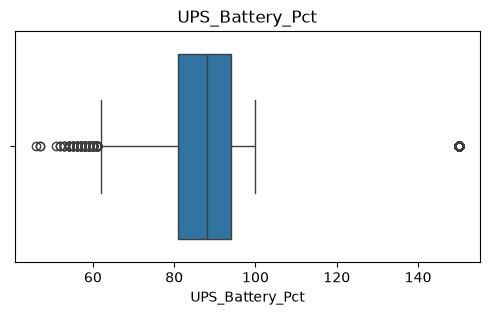

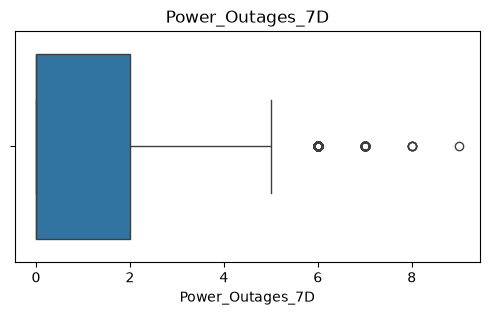

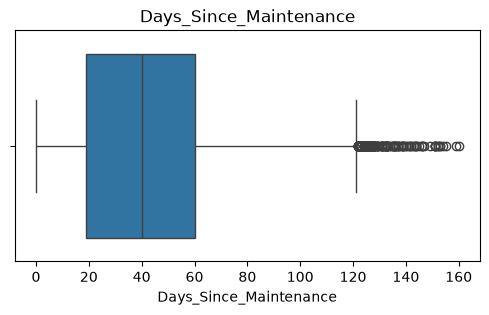

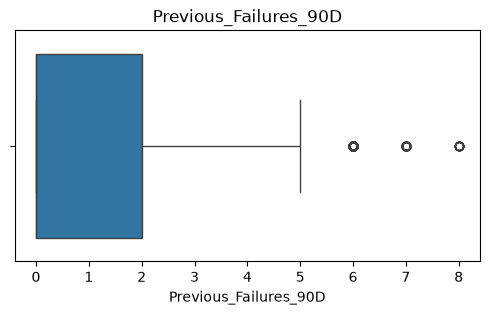

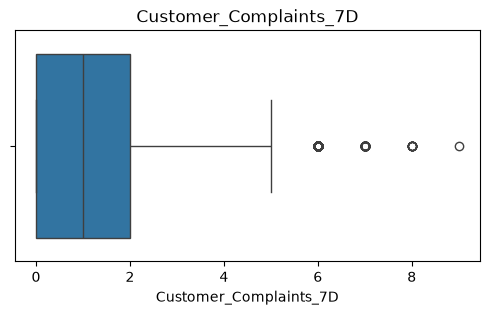

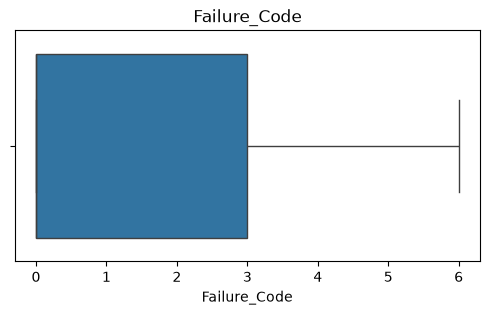

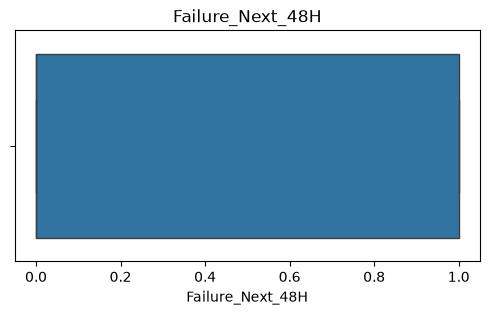

In [24]:
for col in atm.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=atm[col])
    plt.title(col)
    plt.show()

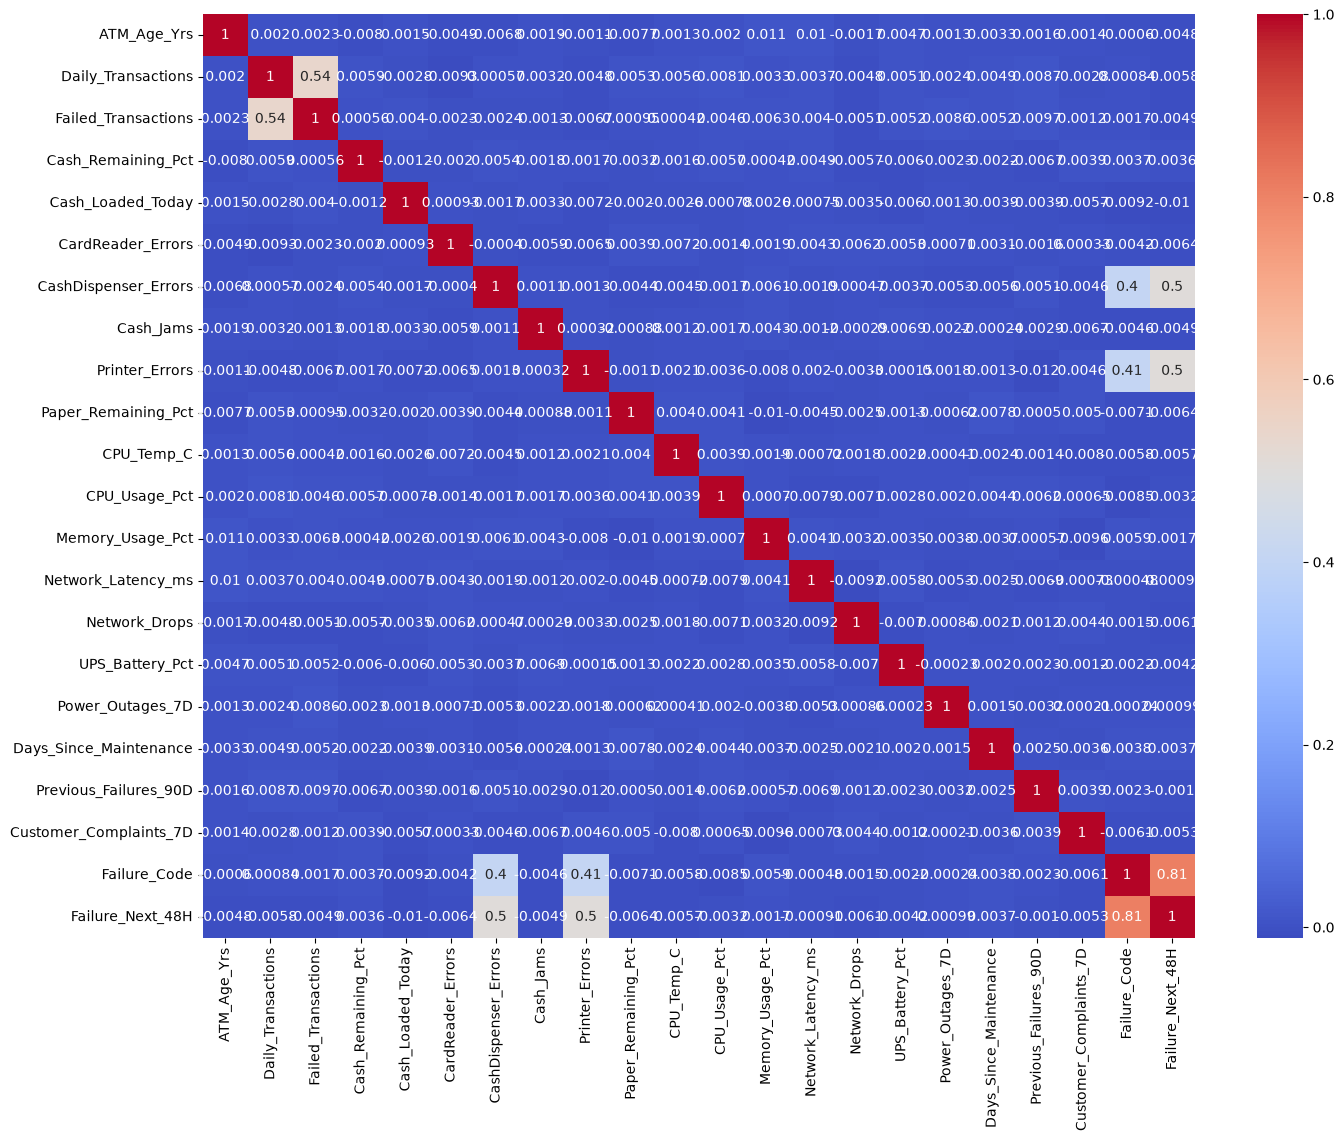

In [25]:
plt.figure(figsize=(16,12))
sns.heatmap(atm.corr(numeric_only=True),
            cmap="coolwarm",
            annot=True)

plt.show()

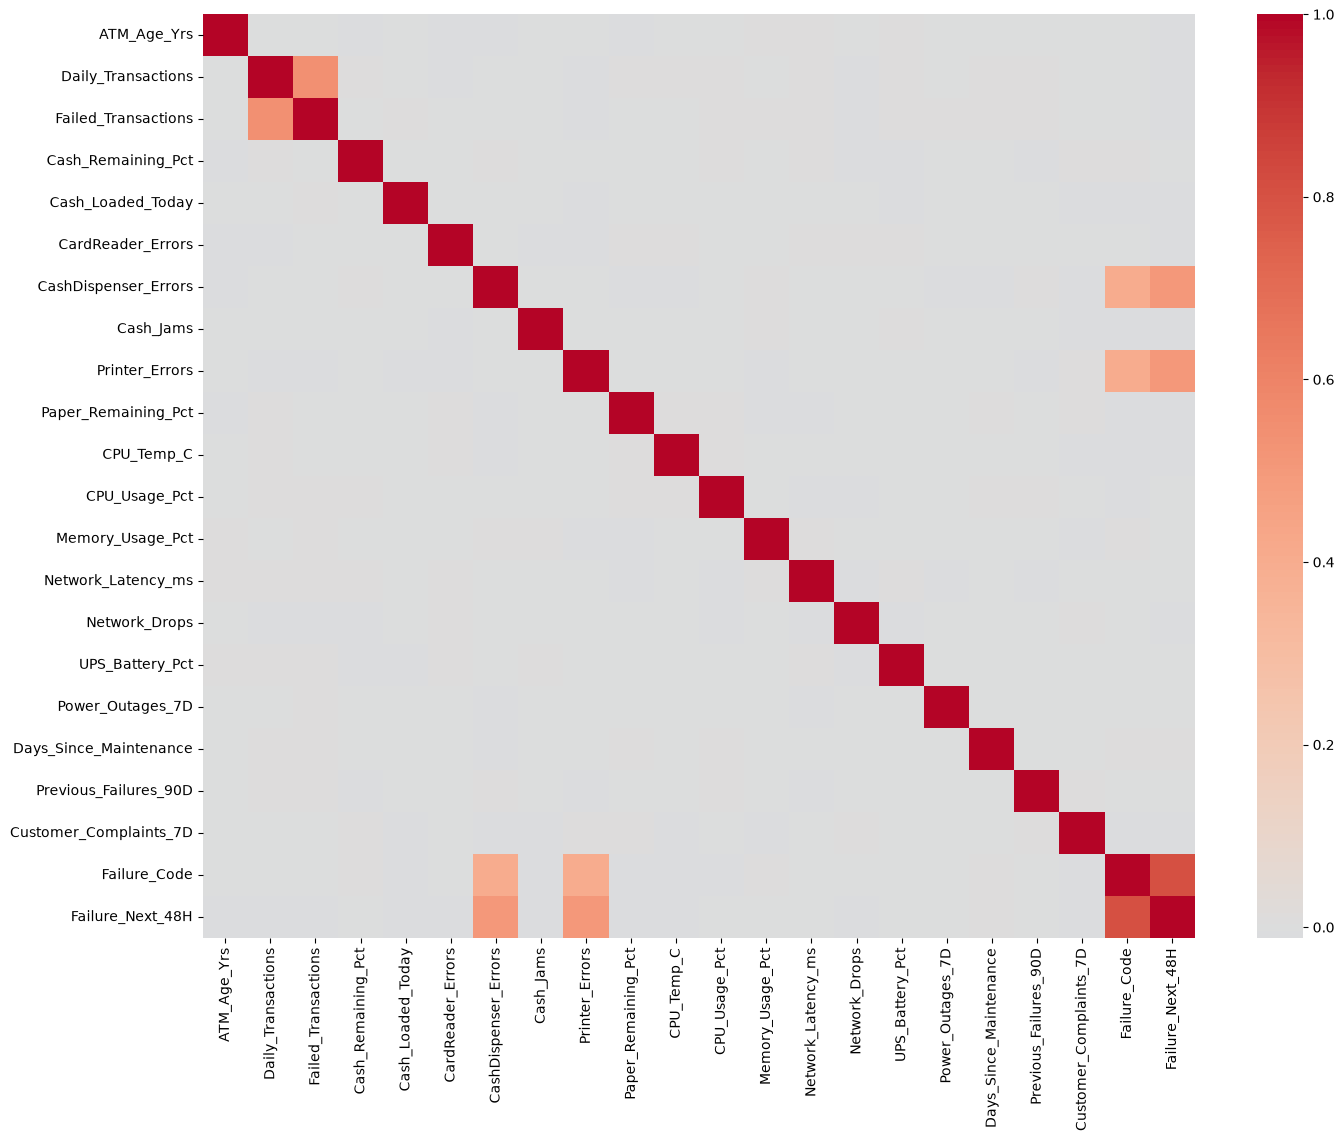

In [26]:
plt.figure(figsize=(16,12))
sns.heatmap(atm.corr(numeric_only=True),
            cmap="coolwarm",
            center=0)

plt.show()

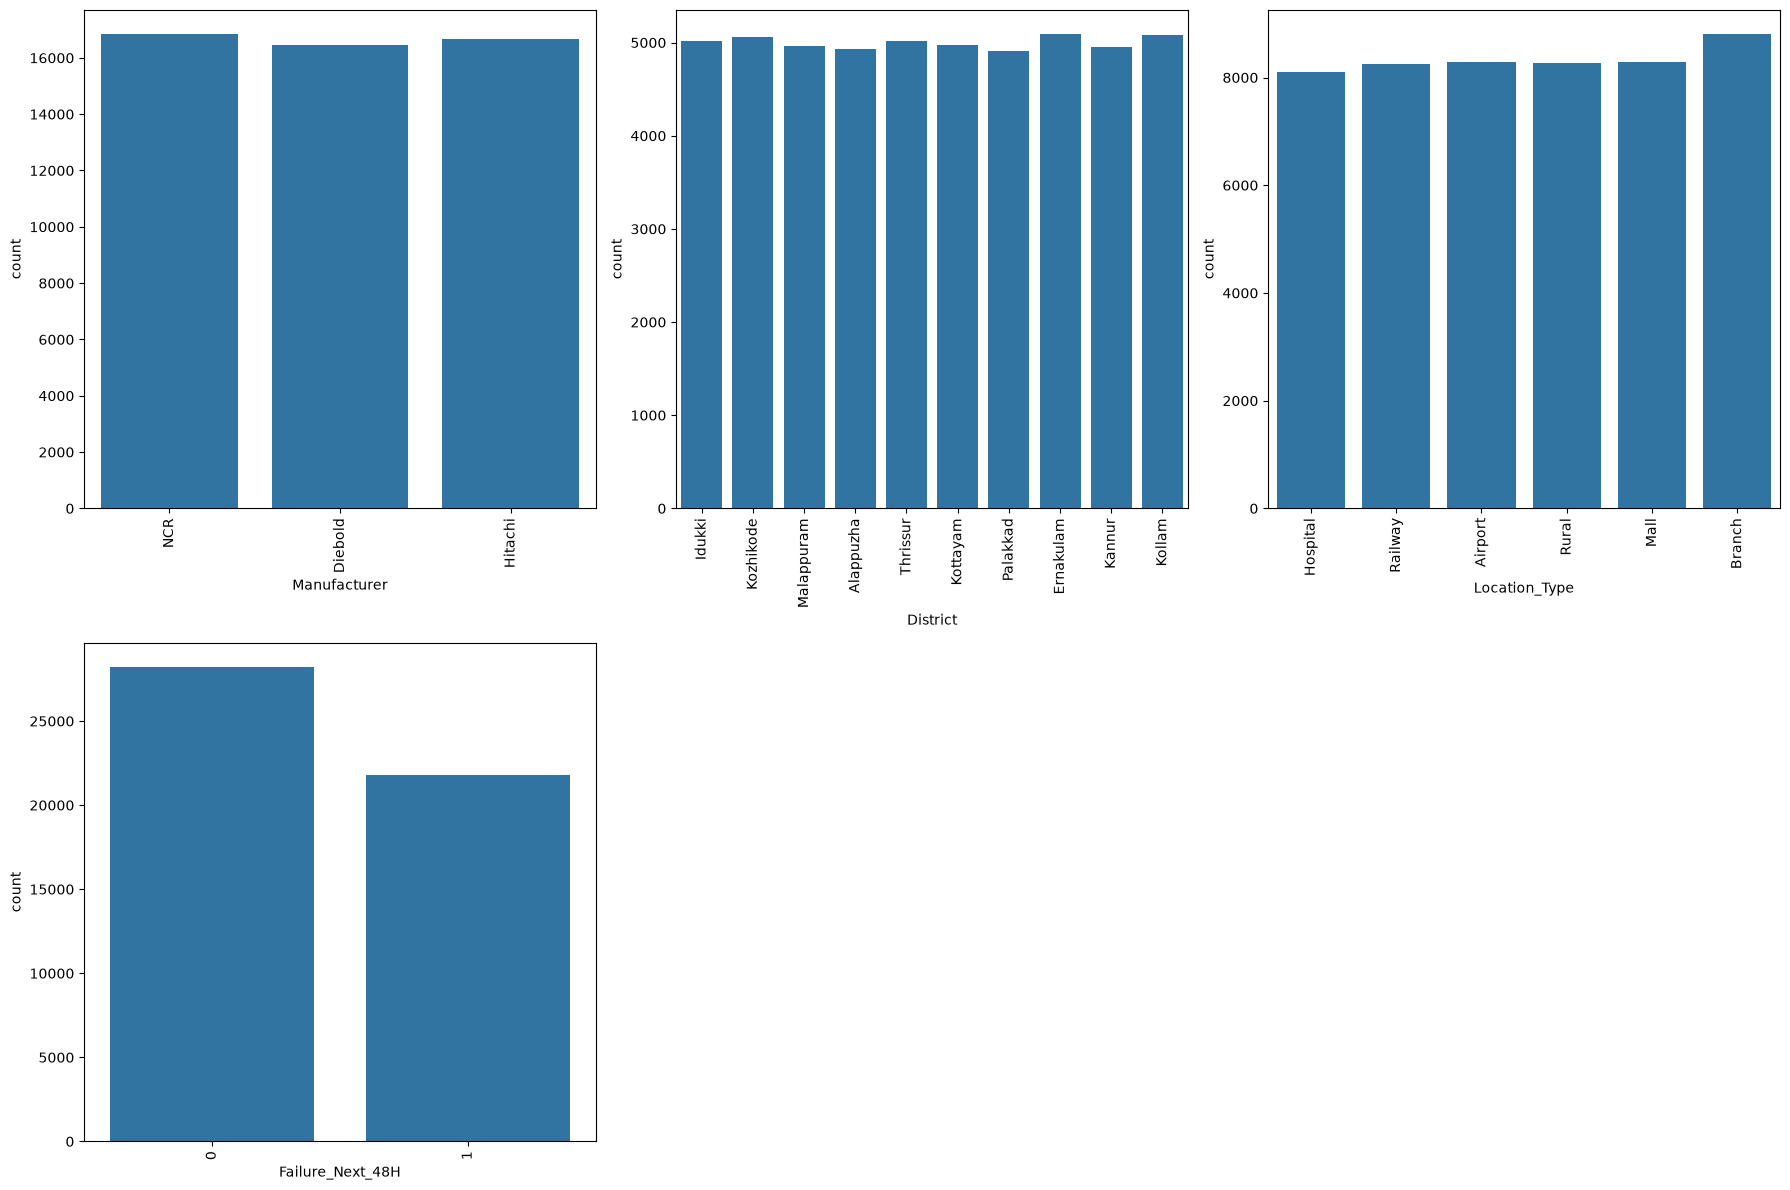

In [27]:
plt.figure(figsize=(18,12))

plt.subplot(2,3,1)
sns.countplot(data=atm,x="Manufacturer")
plt.xticks(rotation=90)

plt.subplot(2,3,2)
sns.countplot(data=atm,x="District")
plt.xticks(rotation=90)

plt.subplot(2,3,3)
sns.countplot(data=atm,x="Location_Type")
plt.xticks(rotation=90)

plt.subplot(2,3,4)
sns.countplot(data=atm,x="Failure_Next_48H")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

- The distribution is fairly balanced across all manufacturers, reducing the likelihood of manufacturer bias in the dataset.
- ATM records are fairly evenly distributed across districts, indicating good geographical representation in the dataset.
- ATM locations are well balanced across different location types.
- Here above 25000 (almost 28000) ATM's doesn't have any failure within 48 hours.
- Almost 22000 ATM's failure with in 48 hours.

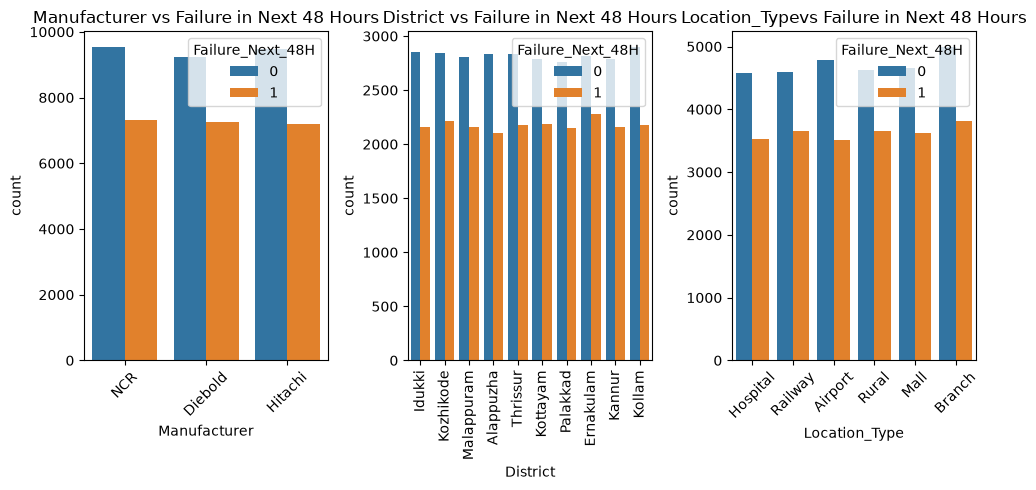

In [28]:
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
sns.countplot(data=atm, x="Manufacturer", hue="Failure_Next_48H")
plt.title("Manufacturer vs Failure in Next 48 Hours")
plt.xticks(rotation=45)

plt.subplot(1,3,2)
sns.countplot(data=atm, x="District", hue="Failure_Next_48H")
plt.title("District vs Failure in Next 48 Hours")
plt.xticks(rotation=90)

plt.subplot(1,3,3)
sns.countplot(data=atm, x="Location_Type", hue="Failure_Next_48H")
plt.title("Location_Typevs Failure in Next 48 Hours")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

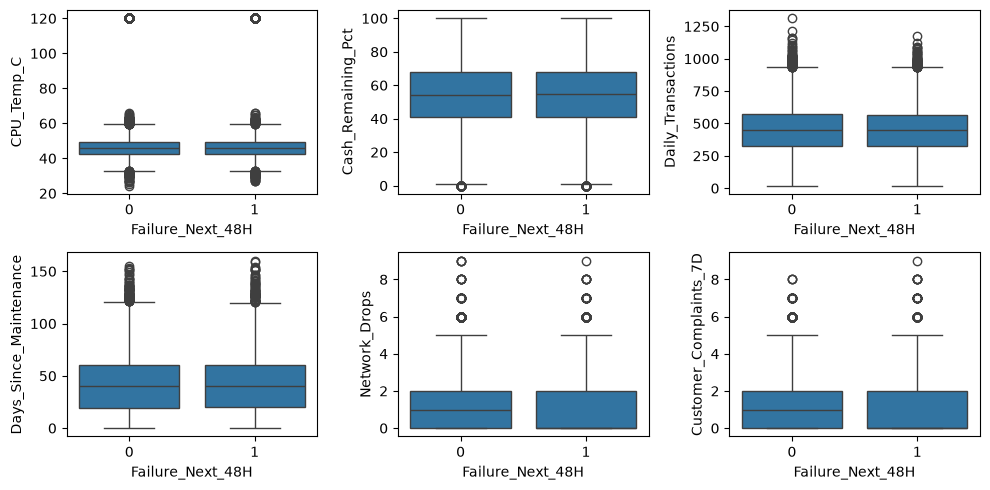

In [29]:
plt.figure(figsize=(10,5))

plt.subplot(2,3,1)
sns.boxplot(data=atm, x="Failure_Next_48H", y="CPU_Temp_C")

plt.subplot(2,3,2)
sns.boxplot(data=atm, x="Failure_Next_48H", y="Cash_Remaining_Pct")

plt.subplot(2,3,3)
sns.boxplot(data=atm, x="Failure_Next_48H", y="Daily_Transactions")

plt.subplot(2,3,4)
sns.boxplot(data=atm, x="Failure_Next_48H", y="Days_Since_Maintenance")

plt.subplot(2,3,5)
sns.boxplot(data=atm, x="Failure_Next_48H", y="Network_Drops")

plt.subplot(2,3,6)
sns.boxplot(data=atm, x="Failure_Next_48H", y="Customer_Complaints_7D")

plt.tight_layout()
plt.show()

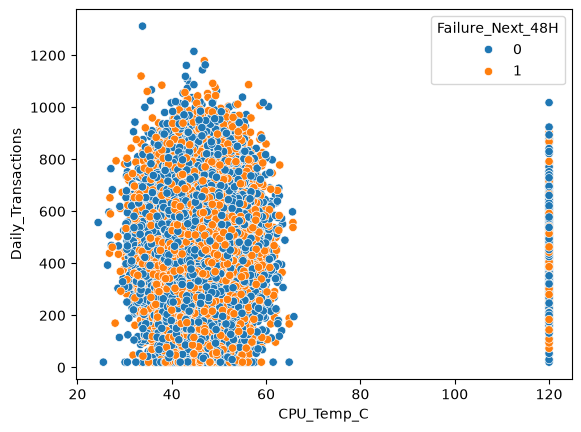

In [30]:
sns.scatterplot(x="CPU_Temp_C", y="Daily_Transactions", hue="Failure_Next_48H", data=atm)
plt.show()